In [2]:
%pip install statsmodels

  Using cached patsy-1.0.2-py2.py3-none-any.whl.metadata (3.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 20.9 MB/s  0:00:00.9 MB/s eta 0:00:01
Using cached patsy-1.0.2-py2.py3-none-any.whl (233 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [statsmodels] 1/2 [statsmodels]
Note: you may need to restart the kernel to use updated packages.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import warnings

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings("ignore")

In [2]:
LOOKBACK = 180
HORIZON = 1   # change to 1, 7, or 30
CUTOFF = pd.Timestamp("2016-01-01")

SAVE_DIR = f"sarima_sirikit_{HORIZON}day"
os.makedirs(SAVE_DIR, exist_ok=True)

In [3]:
CSV_PATH = r"Level2_5140_1974_Sirikit.csv"

df = pd.read_csv(CSV_PATH)
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").dropna(subset=["Storage_km3"]).reset_index(drop=True)

print("Data shape:", df.shape)
print(df.head())
print(df.tail())

Data shape: (13169, 2)
        Date  Storage_km3
0 1987-12-12     4.064504
1 1987-12-13     4.065823
2 1987-12-14     4.067143
3 1987-12-15     4.068463
4 1987-12-16     4.069783
            Date  Storage_km3
13164 2023-12-27     5.316066
13165 2023-12-28     5.314915
13166 2023-12-29     5.313879
13167 2023-12-30     5.312958
13168 2023-12-31     5.312153


In [4]:
train_df = df[df["Date"] < CUTOFF].copy()
test_df  = df[df["Date"] >= CUTOFF].copy()

print("Train:", train_df["Date"].min(), "→", train_df["Date"].max(), "n =", len(train_df))
print("Test :", test_df["Date"].min(), "→", test_df["Date"].max(), "n =", len(test_df))

Train: 1987-12-12 00:00:00 → 2015-12-31 00:00:00 n = 10247
Test : 2016-01-01 00:00:00 → 2023-12-31 00:00:00 n = 2922


In [5]:
scaler = StandardScaler().fit(train_df[["Storage_km3"]])

train_s = scaler.transform(train_df[["Storage_km3"]]).flatten()
test_s  = scaler.transform(test_df[["Storage_km3"]]).flatten()

print("train_s:", train_s.shape)
print("test_s :", test_s.shape)

train_s: (10247,)
test_s : (2922,)


In [6]:
def make_target_windows(series, lookback=180, horizon=30, stride=1):
    y = []
    for i in range(0, len(series) - lookback - horizon + 1, stride):
        y.append(series[i+lookback:i+lookback+horizon])
    return np.asarray(y, dtype=np.float32)

y_test_s = make_target_windows(
    test_s,
    lookback=LOOKBACK,
    horizon=HORIZON
)

print("y_test_s:", y_test_s.shape)

y_test_s: (2742, 1)


In [7]:
# SARIMA/SARIMAX notation:
# order=(p,d,q)
# seasonal_order=(P,D,Q,s)

sarima_model = SARIMAX(
    train_s,
    order=(2, 1, 2),
    seasonal_order=(1, 0, 1, 7),   # weekly seasonality
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_result = sarima_model.fit(disp=False)

print(sarima_result.summary())

                                      SARIMAX Results                                      
Dep. Variable:                                   y   No. Observations:                10247
Model:             SARIMAX(2, 1, 2)x(1, 0, [1], 7)   Log Likelihood               50867.386
Date:                             Sun, 07 Jun 2026   AIC                        -101720.771
Time:                                     15:27:48   BIC                        -101670.136
Sample:                                          0   HQIC                       -101703.651
                                           - 10247                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.9031      0.003    680.771      0.000       1.898       1.909
ar.L2         -0.9174      

In [10]:
sarima_result.save(f"{SAVE_DIR}/sarima_{HORIZON}day_model.pkl")
print("Saved SARIMA model.")

Saved SARIMA model.


In [8]:
n_test_samples = y_test_s.shape[0]

y_pred_s = np.zeros((n_test_samples, HORIZON), dtype=np.float32)

# Start from the model fitted on training data
current_result = sarima_result

for i in range(n_test_samples):
    # For sample i, forecast origin is test index i + LOOKBACK.
    # The model should know observed test data up to that point.
    
    if i == 0:
        # Add first LOOKBACK observed test values
        new_obs = test_s[:LOOKBACK]
    else:
        # Add one new observed value each step
        new_obs = test_s[LOOKBACK + i - 1 : LOOKBACK + i]
    
    current_result = current_result.append(new_obs, refit=False)
    
    forecast_s = current_result.forecast(steps=HORIZON)
    y_pred_s[i, :] = forecast_s

    if (i + 1) % 250 == 0:
        print(f"Forecasted {i+1}/{n_test_samples}")

print("Done SARIMA walk-forward forecasting.")
print("y_pred_s:", y_pred_s.shape)

Forecasted 250/2742
Forecasted 500/2742
Forecasted 750/2742
Forecasted 1000/2742
Forecasted 1250/2742
Forecasted 1500/2742
Forecasted 1750/2742
Forecasted 2000/2742
Forecasted 2250/2742
Forecasted 2500/2742
Done SARIMA walk-forward forecasting.
y_pred_s: (2742, 1)


In [9]:
y_pred = scaler.inverse_transform(y_pred_s.reshape(-1, 1)).reshape(-1, HORIZON)
y_true = scaler.inverse_transform(y_test_s.reshape(-1, 1)).reshape(-1, HORIZON)

print("y_pred:", y_pred.shape)
print("y_true:", y_true.shape)

y_pred: (2742, 1)
y_true: (2742, 1)


In [10]:
rmse_sarima = np.sqrt(np.mean((y_true - y_pred) ** 2))
mae_sarima = np.mean(np.abs(y_true - y_pred))
r2_sarima = r2_score(y_true.reshape(-1), y_pred.reshape(-1))

print(f"\n[SARIMA Test Forecast | Horizon={HORIZON}]")
print(f"RMSE = {rmse_sarima:.6f} km³")
print(f"MAE  = {mae_sarima:.6f} km³")
print(f"R²   = {r2_sarima:.6f}")


[SARIMA Test Forecast | Horizon=1]
RMSE = 0.002334 km³
MAE  = 0.001164 km³
R²   = 0.999996


In [11]:
rows = []

print("\nPer-step SARIMA metrics:")
for h in range(HORIZON):
    rmse_h = np.sqrt(mean_squared_error(y_true[:, h], y_pred[:, h]))
    mae_h = mean_absolute_error(y_true[:, h], y_pred[:, h])
    r2_h = r2_score(y_true[:, h], y_pred[:, h])

    rows.append({
        "Model": "SARIMA",
        "Input": "Storage",
        "Lookback": LOOKBACK,
        "Horizon": HORIZON,
        "Step": h + 1,
        "RMSE_km3": rmse_h,
        "MAE_km3": mae_h,
        "R2": r2_h
    })

    print(f"Day {h+1:02d}: RMSE={rmse_h:.6f} | MAE={mae_h:.6f} | R²={r2_h:.6f}")

sarima_metrics_df = pd.DataFrame(rows)
# sarima_metrics_df.to_csv(f"{SAVE_DIR}/sarima_{HORIZON}day_per_step_metrics.csv", index=False)

sarima_metrics_df.head()


Per-step SARIMA metrics:
Day 01: RMSE=0.002334 | MAE=0.001164 | R²=0.999996


,Model,Input,Lookback,Horizon,Step,RMSE_km3,MAE_km3,R2
0,SARIMA,Storage,180,1,1,0.002334,0.001164,0.999996


In [12]:
sarima_result_df = pd.DataFrame([{
    "Model": "SARIMA",
    "Input": "Storage",
    "Lookback": LOOKBACK,
    "Horizon": HORIZON,
    "RMSE_km3": rmse_sarima,
    "MAE_km3": mae_sarima,
    "R2": r2_sarima
}])

sarima_result_df.to_csv(f"{SAVE_DIR}/sarima_{HORIZON}day_final_result_row.csv", index=False)
sarima_result_df

,Model,Input,Lookback,Horizon,RMSE_km3,MAE_km3,R2
0,SARIMA,Storage,180,1,0.002334,0.001164,0.999996


In [13]:
np.save(f"{SAVE_DIR}/sarima_{HORIZON}day_y_true.npy", y_true)
np.save(f"{SAVE_DIR}/sarima_{HORIZON}day_y_pred.npy", y_pred)

print("Saved SARIMA predictions.")

Saved SARIMA predictions.


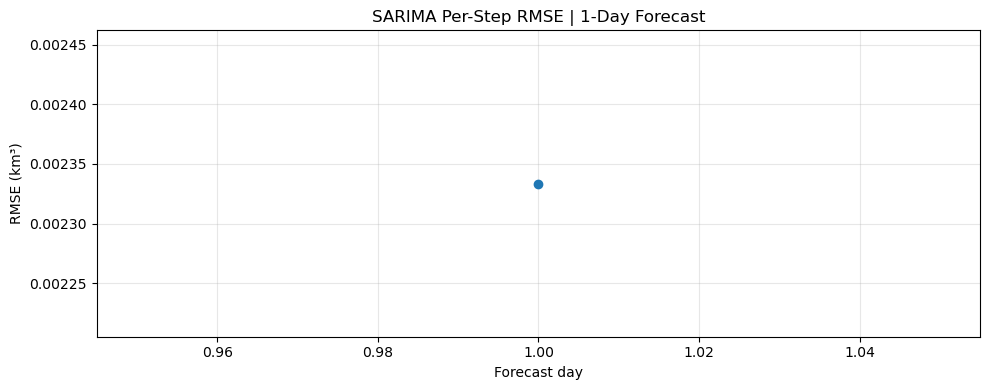

In [14]:
plt.figure(figsize=(10, 4))
plt.plot(sarima_metrics_df["Step"], sarima_metrics_df["RMSE_km3"], marker="o")
plt.xlabel("Forecast day")
plt.ylabel("RMSE (km³)")
plt.title(f"SARIMA Per-Step RMSE | {HORIZON}-Day Forecast")
plt.grid(True, alpha=0.3)
plt.tight_layout()
# plt.savefig(f"{SAVE_DIR}/sarima_{HORIZON}day_per_step_rmse.png", dpi=300)
plt.show()

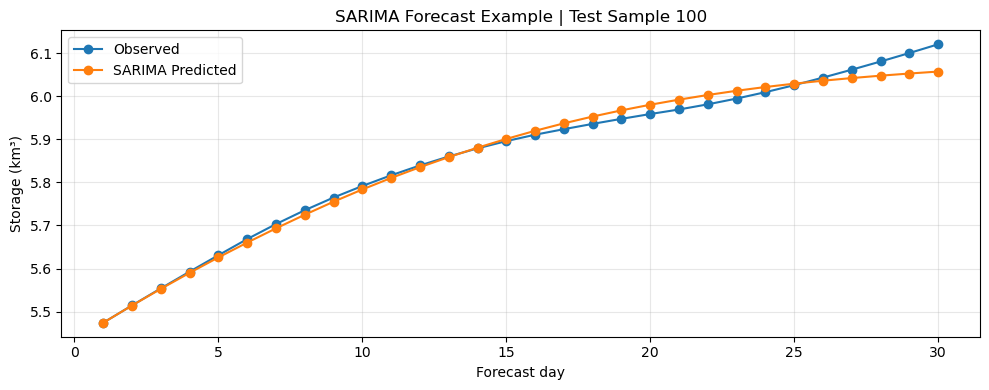

In [18]:
sample_idx = 100

plt.figure(figsize=(10, 4))
plt.plot(range(1, HORIZON + 1), y_true[sample_idx], marker="o", label="Observed")
plt.plot(range(1, HORIZON + 1), y_pred[sample_idx], marker="o", label="SARIMA Predicted")
plt.xlabel("Forecast day")
plt.ylabel("Storage (km³)")
plt.title(f"SARIMA Forecast Example | Test Sample {sample_idx}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/sarima_{HORIZON}day_sample_forecast.png", dpi=300)
plt.show()

In [19]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)
print(LOOKBACK, HORIZON)

NameError: name 'X_train' is not defined